# Regresión Lineal: solución analítica vs descenso de gradiente

Este notebook compara dos formas de entrenar un modelo de regresión lineal:

1. **Solución analítica (clásica)** con scikit-learn
2. **Descenso de gradiente** implementado paso a paso

Ambos métodos minimizan la misma función de pérdida, pero lo hacen de forma diferente.


In [107]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

## 1. Generación de datos

Creamos datos con relación aproximadamente lineal:

y = 4 + 3x + ruido

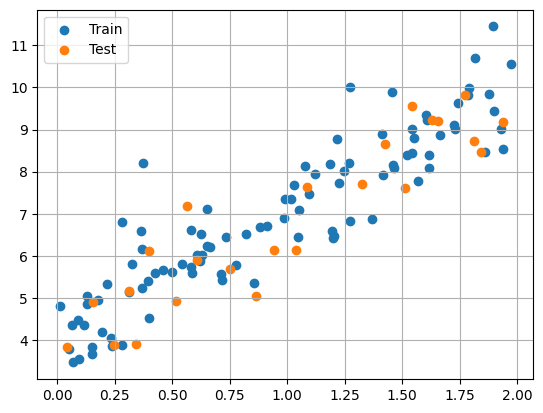

In [108]:
np.random.seed(42)
X = 2 * np.random.rand(120,1)
y = 4 + 3 * X[:,0] + np.random.randn(120)*0.8

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

plt.scatter(X_train,y_train,label='Train')
plt.scatter(X_test,y_test,label='Test')
plt.legend()
plt.grid()
plt.show()

## 2. Solución analítica (scikit-learn)

Calcula directamente los coeficientes sin iteraciones.

In [109]:
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)

print(f'Intercepto: {model.intercept_:.4f}')
print(f'Coeficiente: {model.coef_[0]:.4f}')
print(f'Test MSE: {mse:.4f}')



Intercepto: 4.1913
Coeficiente: 2.9106
Test MSE: 0.6439


## 3. Descenso de gradiente

Entrenamos el modelo iterativamente.

Actualizamos los parámetros con:

$
w \leftarrow w - \eta \cdot \frac{\partial MSE}{\partial w}
$

$
b \leftarrow b - \eta \cdot \frac{\partial MSE}{\partial b}
$

Siendo $\eta$ el ratio de aprendizaje (learning rate)


In [110]:
def grad_desc(X,y,lr=0.05,epochs=100):
    x = X[:,0]
    w,b = 0,0
    n=len(x)
    losses=[]
    for _ in range(epochs):
        y_pred = w*x + b
        error = y_pred - y
        loss = np.mean(error**2)
        losses.append(loss)
        dw = (2/n)*np.sum(error*x)
        db = (2/n)*np.sum(error)
        w -= lr*dw
        b -= lr*db
    return w,b,losses

In [111]:
w,b,losses = grad_desc(X_train,y_train)
y_pred_gd = w*X_test[:,0] + b
mse_gd = mean_squared_error(y_test,y_pred_gd)


print(f'Intercepto: {b:.4f}')
print(f'Coeficiente: {w:.4f}')
print(f'Test MSE: {mse_gd:.4f}')

Intercepto: 4.0263
Coeficiente: 3.0565
Test MSE: 0.6401


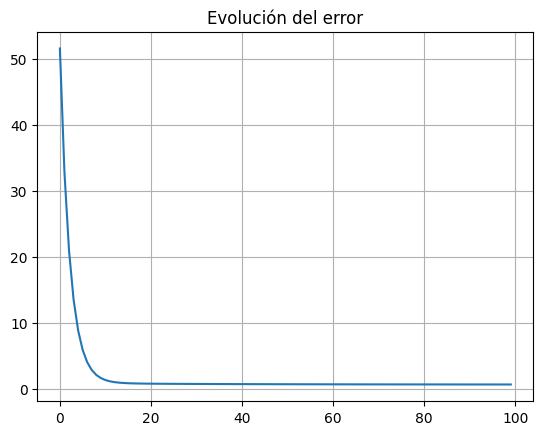

In [112]:
plt.plot(losses)
plt.title('Evolución del error')
plt.grid()
plt.show()

## 4. Comparación

Ambos métodos llegan a resultados similares.

- Solución analítica → directa
- Descenso de gradiente → iterativa

## 5. Ejercicios

1. Cambia el learning rate
2. Cambia el número de iteraciones
3. Añade más ruido
4. Compara resultados